In [1]:
import pandas as pd
from joblib import load
from sklearn.metrics import *
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd()
PROJECT_DIR = BASE_DIR
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"

In [3]:
plt.rcParams["font.family"] = ["Microsoft JhengHei"]

In [4]:
data = pd.read_csv(f'{DATA_DIR}/v1/function_dataset_reset.csv')

In [5]:
X = data.drop(['label'], axis=1)
y = data['label']

In [6]:
train_rows = int(len(data)*0.8)
X_train = X.iloc[:train_rows].copy()
X_test = X.iloc[train_rows:].copy()
y_train = y.iloc[:train_rows].copy()
y_test = y.iloc[train_rows:].copy()

In [7]:
# 載入最終模型
model_package = load(f'{MODEL_DIR}/v1/final_model.joblib')

In [8]:
final_model = model_package['model']
final_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('DecisionTree', ...), ('RandomForest', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",Pipeline(step...m_state=10))])
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, defau

In [9]:
feature_names = model_package['feature_names']

In [10]:
train_pred = final_model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
test_pred = final_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

In [11]:
print("----最終結果----")
print(f"訓練數據準確度: {train_acc:.4f}")
print(f"測試數據準確度: {test_acc:.4f}")

----最終結果----
訓練數據準確度: 0.9866
測試數據準確度: 0.7125


In [12]:
print(f"混淆矩陣:\n{confusion_matrix(y_test, test_pred)}")

混淆矩陣:
[[33  0  0  0  1  0  3 63]
 [ 0 95  4  0  0  1  0  0]
 [ 1  1 70  9 15  4  0  0]
 [ 0  0  0 59 37  0  4  0]
 [ 2  0  0 18 75  1  1  3]
 [ 0  0  2  1 12 85  0  0]
 [ 2  0  0  1  3  0 92  2]
 [36  0  0  0  2  0  1 61]]


In [13]:
labels = ["linear", "quadratic", "cubic", "exponential", "logarithmic", "sine", "cosine", "reciprocal"]

C:\Users\user\AppData\Local\Temp\ipykernel_30588\220775606.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


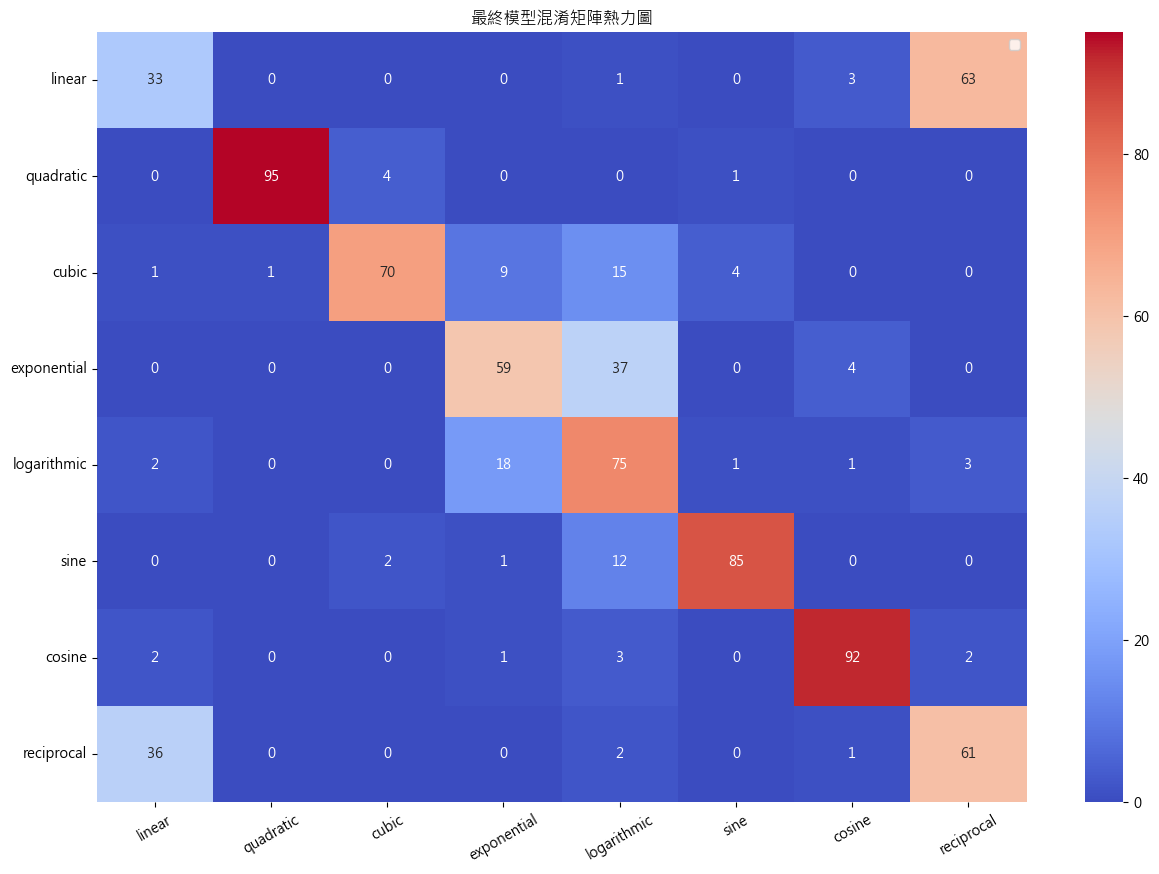

In [14]:
plt.figure(figsize=(15, 10))
sns.heatmap(confusion_matrix(y_test, test_pred), 
            cmap='coolwarm', 
            xticklabels=[i for i in labels], 
            yticklabels=[i for i in labels],
            annot=True)
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.title('最終模型混淆矩陣熱力圖')
plt.legend()
plt.savefig(f'{DATA_DIR}/v1/v1_results.png')
plt.show()

In [15]:
print(f"分類報告:\n{classification_report(y_test, test_pred)}")

分類報告:
              precision    recall  f1-score   support

      cosine       0.45      0.33      0.38       100
       cubic       0.99      0.95      0.97       100
 exponential       0.92      0.70      0.80       100
      linear       0.67      0.59      0.63       100
 logarithmic       0.52      0.75      0.61       100
   quadratic       0.93      0.85      0.89       100
  reciprocal       0.91      0.92      0.92       100
        sine       0.47      0.61      0.53       100

    accuracy                           0.71       800
   macro avg       0.73      0.71      0.72       800
weighted avg       0.73      0.71      0.72       800

